In [2]:
%matplotlib inline

In [3]:
import geopandas

In [4]:
import pandas as pd

In [5]:
pd.options.display.max_rows = 4

In [6]:
from matplotlib import pyplot as plt

In [7]:
# Import earthpy to use for reprojecting data; conda install -c conda-forge earthpy see https://pypi.org/project/earthpy/

In [8]:
import earthpy as et

This dataset is a collection of the current base zone designations applied to property in the City of San Diego which picked from the https://data.sandiego.gov/datasets/

In [9]:
data = geopandas.read_file("../project3/sd/zoning/zoning_datasd.shp")

In [10]:
# Identify the coordinate system
print(data.crs)

epsg:2230


In [11]:
data

,objectid,zone_name,imp_date,ordnum,geometry
0,1,AG-1-1,2006-02-28,R-301263,"POLYGON ((6292168.173 1961735.236, 6292134.998..."
1,2,AG-1-1,2006-02-28,R-301263,"POLYGON ((6292231.783 1961769.873, 6292233.158..."
...,...,...,...,...,...
3692,3693,CC-4-2,2006-02-28,R-301263,"POLYGON ((6265523.929 1873767.931, 6265419.003..."
3693,3694,CC-3-8,2021-12-17,R-313753,"POLYGON ((6265547.612 1873706.217, 6265427.264..."


In [12]:
print(data)

      objectid zone_name    imp_date    ordnum  \
0            1    AG-1-1  2006-02-28  R-301263   
1            2    AG-1-1  2006-02-28  R-301263   
...        ...       ...         ...       ...   
3692      3693    CC-4-2  2006-02-28  R-301263   
3693      3694    CC-3-8  2021-12-17  R-313753   

                                               geometry  
0     POLYGON ((6292168.173 1961735.236, 6292134.998...  
1     POLYGON ((6292231.783 1961769.873, 6292233.158...  
...                                                 ...  
3692  POLYGON ((6265523.929 1873767.931, 6265419.003...  
3693  POLYGON ((6265547.612 1873706.217, 6265427.264...  

[3694 rows x 5 columns]


In [13]:
data = data.drop(0)

In [14]:
data.head(3)

,objectid,zone_name,imp_date,ordnum,geometry
1,2,AG-1-1,2006-02-28,R-301263,"POLYGON ((6292231.783 1961769.873, 6292233.158..."
2,3,AG-1-1,2006-02-28,R-301263,"POLYGON ((6293152.811 1962306.294, 6293225.417..."
3,4,AG-1-1,2006-02-28,R-301263,"POLYGON ((6295127.291 1964683.329, 6295598.036..."


In [15]:
# Calculate the area of each polygon:

In [16]:
data.geometry.area

1        42461.388397
2       230715.100073
            ...      
3692    112110.880781
3693      6329.545408
Length: 3693, dtype: float64

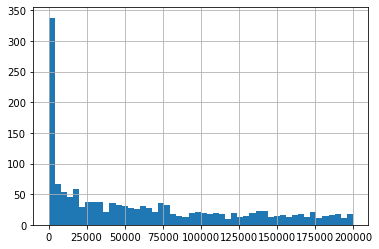

In [17]:
data.geometry.area.hist(bins=50, range=(0,0.2e6))

In [18]:
# Plot the shapes with coloring based on anohter column

The code below shows the max and min of x,y coordinates for each polygon:

In [19]:
bounds = data.bounds
bounds

,minx,miny,maxx,maxy
1,6.292211e+06,1.961759e+06,6.292988e+06,1.962040e+06
2,6.293076e+06,1.962071e+06,6.294032e+06,1.962672e+06
...,...,...,...,...
3692,6.265034e+06,1.873768e+06,6.265587e+06,1.874555e+06
3693,6.265376e+06,1.873620e+06,6.265548e+06,1.873768e+06


Only polygons with 'zone_name' not equal to "RS-17" are kept in the data:

In [20]:
data = data[data['zone_name'] != 'RS-17']

In [21]:
data

,objectid,zone_name,imp_date,ordnum,geometry
1,2,AG-1-1,2006-02-28,R-301263,"POLYGON ((6292231.783 1961769.873, 6292233.158..."
2,3,AG-1-1,2006-02-28,R-301263,"POLYGON ((6293152.811 1962306.294, 6293225.417..."
...,...,...,...,...,...
3692,3693,CC-4-2,2006-02-28,R-301263,"POLYGON ((6265523.929 1873767.931, 6265419.003..."
3693,3694,CC-3-8,2021-12-17,R-313753,"POLYGON ((6265547.612 1873706.217, 6265427.264..."


In [22]:
# Import descartes to use for plotting polygons in geopandas
import descartes

Polygons are plotted below. Different colors are assigned to different zone in the legend.

Text(0.5, 1.0, 'Base zone designations of San Diego')

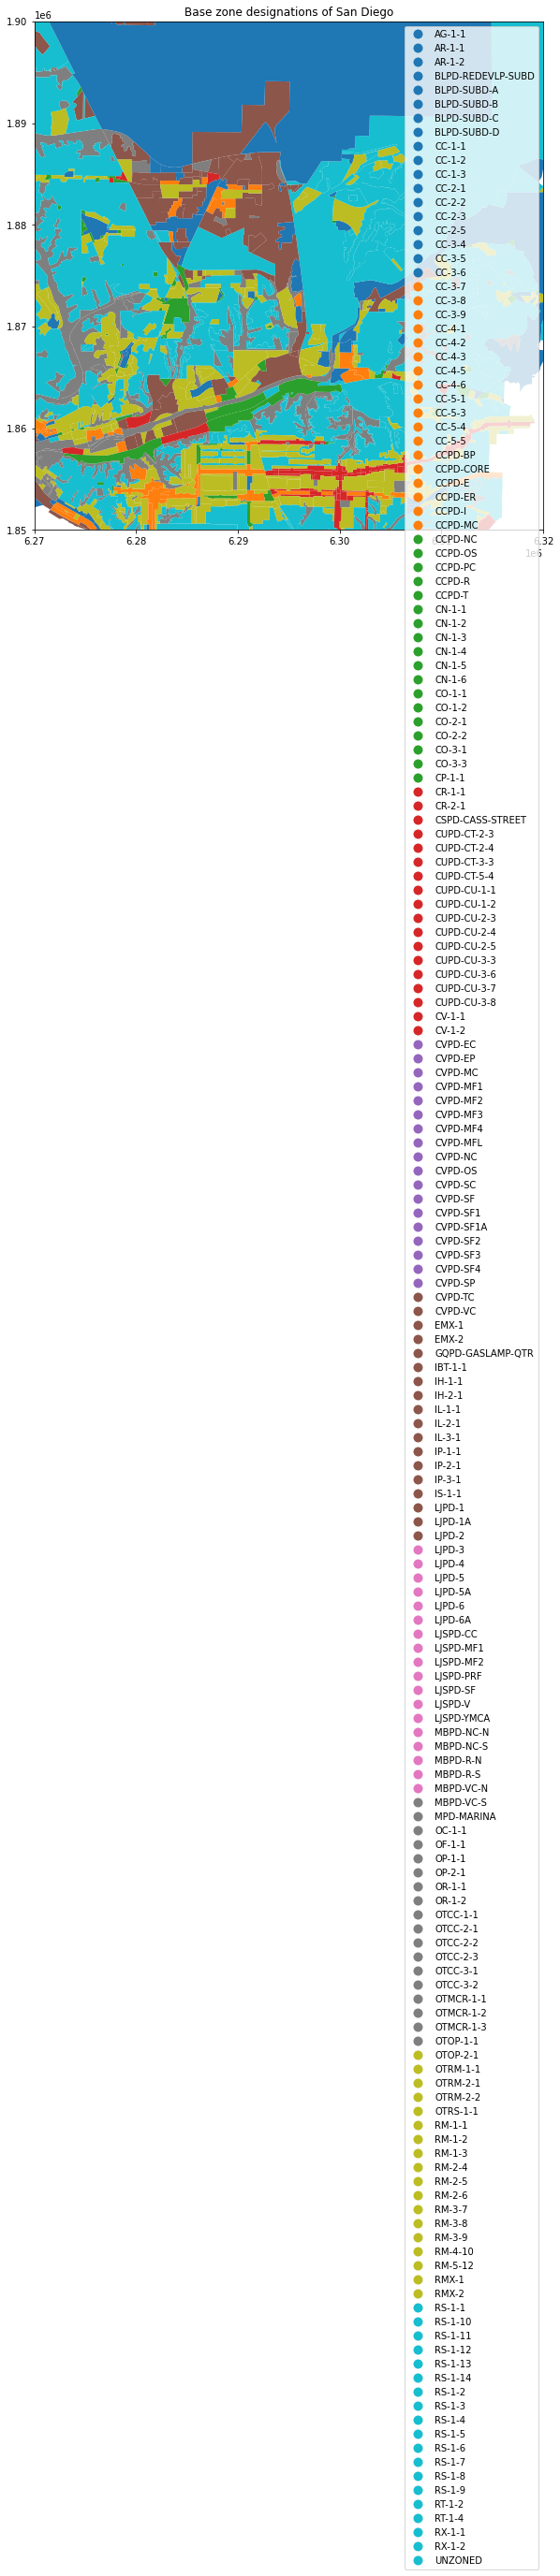

In [25]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
data.plot(column='zone_name', legend=True, ax=ax)
ax.set_xlim(6.27e6, 6.32e6)
ax.set_ylim(1.85e6, 1.90e6)
ax.set_title('Base zone designations of San Diego')

Polygons with zone name 'RS-1-1' are selected to a new geodataframe called 'blue_areas', we can see there are 223 rows and 5 columns in this geodataframe.

In [27]:
blue_areas = data[data['zone_name']== 'RS-1-1']

In [28]:
blue_areas

,objectid,zone_name,imp_date,ordnum,geometry
1607,1608,RS-1-1,2006-02-28,R-301263,"POLYGON ((6304688.589 1787554.312, 6304686.186..."
1608,1609,RS-1-1,2006-02-28,R-301263,"POLYGON ((6303352.502 1787571.009, 6303335.998..."
...,...,...,...,...,...
3520,3521,RS-1-1,2006-02-28,R-301263,"POLYGON ((6308088.921 1865203.120, 6308216.998..."
3521,3522,RS-1-1,2006-02-28,R-301263,"POLYGON ((6300408.044 1864634.696, 6300544.913..."


This dataset contain the roads in San Diego County, here we read as a new geodataframe called 'streets', and both the coordinate system of roads_datasd.shp and zoning_datasd.shp are 2230. No need to reproject this layer. 

In [37]:
streets = geopandas.read_file("../project3/sd/road/roads_datasd.shp")
streets

,objectid,roadsegid,roadid,fnode,tnode,rd20full,rd30full,speed,oneway,firedriv,...,nad_from_y,nad_to_x,nad_to_y,rd20pred,rd20name,rd20sfx,rd30pred,rd30name,rd30sfx,geometry
0,4747,51687,12709,67331,67311,PALOMAR AV,PALOMAR AVE,20,B,Y,...,1882085.00,6246025.00,1882125.00,None,PALOMAR,AV,None,PALOMAR,AVE,"LINESTRING (6245865.000 1882085.000, 6246025.0..."
1,4748,51689,12709,67387,67331,PALOMAR AV,PALOMAR AVE,20,B,Y,...,1882009.00,6245865.00,1882085.00,None,PALOMAR,AV,None,PALOMAR,AVE,"LINESTRING (6245560.000 1882009.000, 6245865.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56867,162663,231024,2791,190502,86502,60TH ST,60TH ST,20,B,Y,...,1854520.74,6310494.00,1854590.00,None,60TH,ST,None,60TH,ST,"LINESTRING (6310503.553 1854520.739, 6310494.0..."
56868,162664,231025,2791,86646,190502,60TH ST,60TH ST,20,B,Y,...,1854416.00,6310503.55,1854520.74,None,60TH,ST,None,60TH,ST,"LINESTRING (6310518.000 1854415.999, 6310514.1..."


In [30]:
strs = (streets.crs) 
print(streets.crs)

epsg:2230


In [31]:
# To display these together, or perform a spatial analysis, do any layers need to be reprojected?...i.e. see https://www.earthdatascience.org/workshops/gis-open-source-python/reproject-vector-data-in-python/

In [32]:
# view the spatial extent of both layers 
print(data.total_bounds)
print(streets.total_bounds)

[6244557.99829322 1775471.50514415 6360822.99771814 1986027.67917532]
[6244786.23025    1776061.97400001 6470258.12525    1986019.70200001]


In [33]:
# view the spatial extent of both layers again 
print(data.total_bounds)
# print(streets_reprojected.total_bounds)

[6244557.99829322 1775471.50514415 6360822.99771814 1986027.67917532]


'blue_areas' and 'streets' are visualized below. Since they have the same corrdinate system, spatial relationship between items in figure are reliable. Blue areas are represented as blue polygons and roads(streets) are represented by grey lines. 

(1850000.0, 1900000.0)

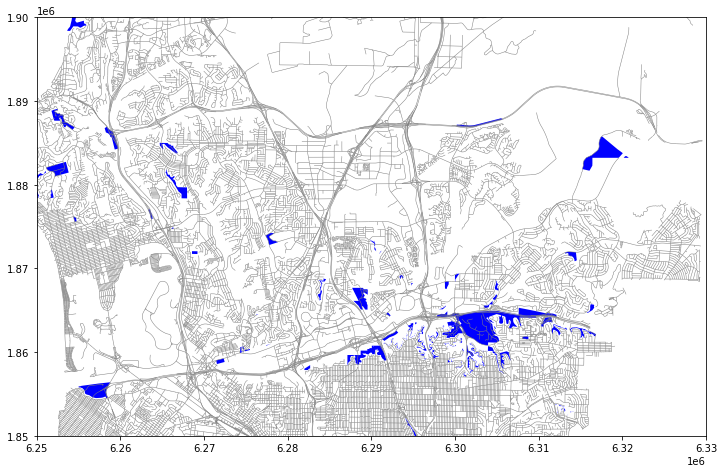

In [34]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
blue_areas.plot(ax=ax, color='blue')
ax.set_xlim(6.25e6, 6.33e6)
ax.set_ylim(1.85e6, 1.9e6)

Text(0.5, 1.0, 'Road lines of San Diego')

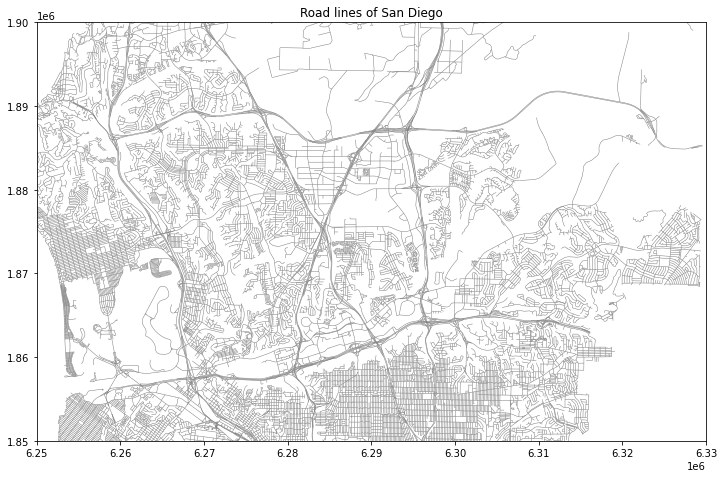

In [36]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
ax.set_xlim(6.25e6, 6.33e6)
ax.set_ylim(1.85e6, 1.9e6)
ax.set_title('Road lines of San Diego')

This figure is the 'streets' layer overlapped with buffered 'blue_areas' layer. We can see polygon in 'blue_areas' layer became buffer of 300 units and then plotted with light blue below.

(1850000.0, 1900000.0)

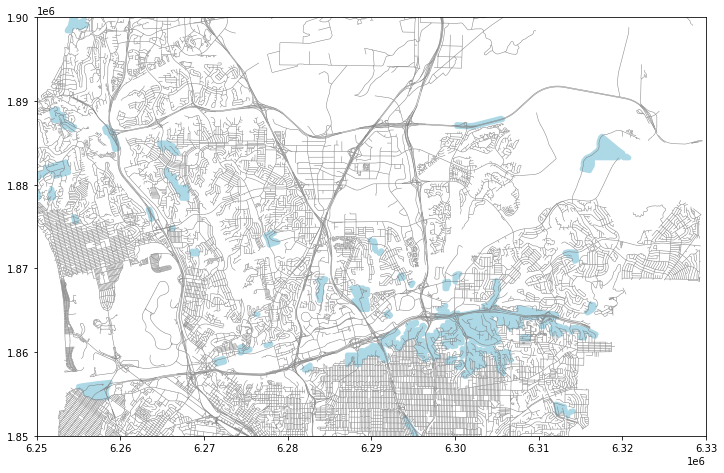

In [67]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
blue_areas.geometry.buffer(300).plot(ax=ax, color='lightblue')
ax.set_xlim(6.25e6, 6.33e6)
ax.set_ylim(1.85e6, 1.9e6)

The dataset below contains the addreess of Recreation centers operated by the City of San Diego Park and Recreation Department. Both the coordinate system of rec_centers_datasd.shp and roads_datasd.shp are 2230. No need to reproject this layer.

In [23]:
rec_centers = geopandas.read_file("../project3/sd/rec_centers/rec_centers_datasd.shp")
rec_centers

,objectid,rec_bldg,park_name,address,zip,sq_ft,year_built,serv_dist,adult_ctr,comfort_st,...,tinytot_rm,weight_rm,current_cd,fy13_cd,facility_n,thomas_bro,community,lat,lng,geometry
0,1,Scripps Ranch Rec Center,Scripps Ranch Community Park,11454 Blue Cypress Dr,92131,12080,2000,40,0,0,...,0,0,5,5,10279,1210-A2,MIRAMAR RANCH NORTH,32.928674,-117.079859,POINT (6307031.787 1918688.516)
1,2,North Park Rec Center,North Park Community Park,4044 Idaho St,92104,11230,1947,41,1,0,...,1,0,3,3,488,1269-D5,NORTH PARK,32.750901,-117.134182,POINT (6289814.973 1854145.623)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,Pacific Highlands Ranch Rec Center,Pacific Highlands Ranch Community Park,5977 Village Loop Rd,92130,17393,2019,40,0,2,...,0,0,1,0,10961,1188-F4,PACIFIC HIGHLANDS RANCH,32.959990,-117.187184,POINT (6274203.382 1930361.211)
57,58,Park de la Cruz Rec Center,Park de la Cruz Neighbohood Park,3901 Landis Steet St,92105,0,0,None,0,0,...,0,0,0,0,0,1269-G6,CITY HEIGHTS,32.745716,-117.110321,POINT (6297135.754 1852197.742)


In [25]:
print(rec_centers.crs)

epsg:2230


In [31]:
# view the spatial extent of all 3 layers 
print(data.total_bounds)
print(streets.total_bounds)
print(rec_centers.total_bounds)

[6244557.99829322 1775471.50514415 6360822.99771814 1986027.67917532]
[6244786.23025    1776061.97400001 6470258.12525    1986019.70200001]
[6245835.31991018 1779655.39564448 6324524.86758327 1962056.37008065]


In [32]:
# view the spatial extent of all 3 layers 
print(data.total_bounds)
print(streets.total_bounds)
print(rec_centers.total_bounds)

[6244557.99829322 1775471.50514415 6360822.99771814 1986027.67917532]
[6244786.23025    1776061.97400001 6470258.12525    1986019.70200001]
[6245835.31991018 1779655.39564448 6324524.86758327 1962056.37008065]


In [33]:
# Print x and y values of all points represent recreation centers in San Diego:
x = rec_centers.geometry.apply(lambda p: p.x)
y = rec_centers.geometry.apply(lambda p: p.y)
print(x,y)

0     6.307032e+06
1     6.289815e+06
          ...     
56    6.274203e+06
57    6.297136e+06
Name: geometry, Length: 58, dtype: float64 0     1.918689e+06
1     1.854146e+06
          ...     
56    1.930361e+06
57    1.852198e+06
Name: geometry, Length: 58, dtype: float64


The locations of recreation centers and roads of SanDiego are plotted in the figure below. Roads represented by grey lines and recreation centers shows as blue point. 

(1850000.0, 1900000.0)

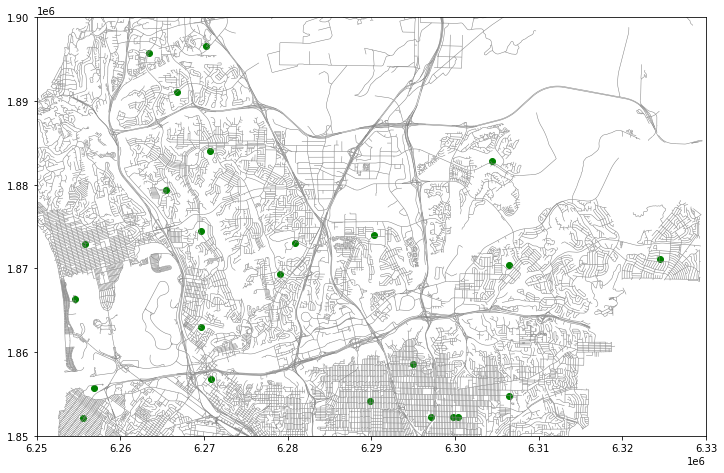

In [44]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
rec_centers.plot(ax=ax, color='green')
ax.set_xlim(6.25e6, 6.33e6)
ax.set_ylim(1.85e6, 1.9e6)

In [35]:
# Question: what is the distance to the nearest blue area for all adresses?

Polygons in data with zone name equal to 'RS-1-1' and area greater than 10000 are created as rec_centers_blue. This geodataframe contains 175 rows and 5 columns.

In [36]:
rec_centers_blue = data[(data['zone_name']=='RS-1-1') & (data.geometry.area > 10000)]

In [37]:
rec_centers_blue

,objectid,zone_name,imp_date,ordnum,geometry
1607,1608,RS-1-1,2006-02-28,R-301263,"POLYGON ((6304688.589 1787554.312, 6304686.186..."
1608,1609,RS-1-1,2006-02-28,R-301263,"POLYGON ((6303352.502 1787571.009, 6303335.998..."
...,...,...,...,...,...
3520,3521,RS-1-1,2006-02-28,R-301263,"POLYGON ((6308088.921 1865203.120, 6308216.998..."
3521,3522,RS-1-1,2006-02-28,R-301263,"POLYGON ((6300408.044 1864634.696, 6300544.913..."


The function here calculates and returns the shortest distance between the point and a polygon in the dataframe. 

After apply this defined function and the codes below, the min_distance between 'RS-1-1' and recreation centers are created and added on rec_centers dataframe.

In [38]:
def rec_centers_blue_dist(point, rec_centers_blue):
    return rec_centers_blue.geometry.distance(point).min()

In [39]:
min_distance = rec_centers.geometry.apply(lambda x: rec_centers_blue_dist(x, rec_centers_blue))

In [40]:
rec_centers['min_distance'] = min_distance

The 'streets' and 'rec_centers' are plotted in the following figure. The 'streets' layer represents the roads in SD and grey line as same as before, but 'rec_centers' are colored with  colormap 'Blues_r' based on values of 'min_distance'. 

Also, the histgram visualize the 'min_distance' in 'rec_centers' as well.

(1850000.0, 1900000.0)

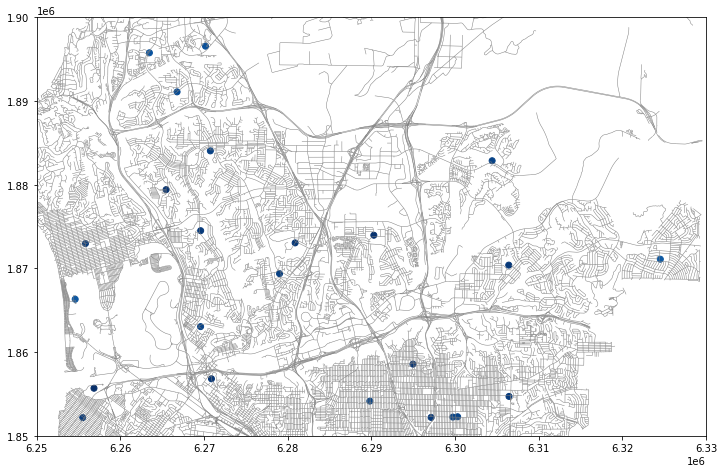

In [41]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
rec_centers.plot(ax=ax, column='min_distance', cmap='Blues_r')
ax.set_xlim(6.25e6, 6.33e6)
ax.set_ylim(1.85e6, 1.9e6)

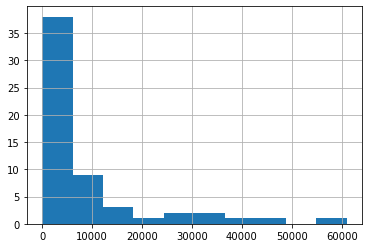

In [42]:
rec_centers['min_distance'].hist()